# These are the Figures for the Paper

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const
import heapq

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as Photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path

current_directory = Path.cwd()
references_directory_path = "Installation&Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation&Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds


## Figures List + What is Needed:
- Figure 1: Spaghetti plot for the H2-rich and one for O2-rich cases. Two panels, one for each scenario.
- Figure 2: One panel. Albedo vs. wavelength for Archean Earth and H2-rich sub-Neptune
- Figure 3: One panel. Albeo vs. wavelength for Modern Earth and O2-rich
- Maybe just one Fig with both Fig 2 and 3 described above
- Figure 4: Two panels. One panel is H2-rich. The other is Archean Earth. for both panels show contributions of Molecules, ground, rayleigh scattering, clouds.
- Figure 5: Same as Figure 4, but just for our O2-rich case and Modern Earth.

## Data Saved: Will need the following
- Phoochem outputs for O2 Rich Mini-Neptune Case that is a good match for Modern Earth
- Photochem outputs for H Rich Mini-Neptune Case that is a good match for Archean Earth
- Reflected Spectrum (RS) of O2 Rich Mini-Neptune Case (closest match with clouds & Earth phase)
- Reflected Spectrum (RS) of H Rich Mini-Neptune Case (closest match with clouds & Earth phase)

Most complicated plot is Figure 5: Need each of these for both the O2 and H Rich Mini-Neptunes
- RS without molecular contribution (do we want to split this up into various molecules??); particularily O3
- RS without rayleigh scattering contribution
- RS without clouds contribution
- RS with a surface???
- RS of O2 Rich Mini-Neptune that is closest to Modern Earth
- RS of H Rich Mini-Neptune that is closest to Archean Earth
- RS of Modern Earth (closest match)
- RS of Archean Earth (closest match)
- RS of Modern Earth without a surface
- RS of Archean Earth without a surface

### Mini-Neptune K218b-like O2 Rich Case Files Needed:

Parameters:
- planet radius: 2.61x Earth
- **metallicity: 3.5x (logspace) x solar (~3000x solar metallicity)**
- tint: 155K
- semi major in AU: 1 AU
- **ctoO_solar: 0.01 x solar c/o ratio**
- kzz: 5 cm^2/s

#### Open Photochemistry of Mini-Neptune O2 Rich K218b like case:

In [2]:
sol_file_path = "sol_2.61_3.5_155_1_0.01_5.pkl"
soleq_file_path = "soleq_2.61_3.5_155_1_0.01_5.pkl"

with open(sol_file_path, 'rb') as file:
    photochem_data_35m_001co_sol = pickle.load(file)
    print(photochem_data_35m_001co_sol.keys())

with open(soleq_file_path, 'rb') as file:
    photochem_data_35m_001co_soleq = pickle.load(file)
    print(photochem_data_35m_001co_soleq.keys())

dict_keys(['pressure', 'temperature', 'Kzz', 'H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3', 'HNO2', 'HNO3', 'N2H4', 'C2H6', 'CH3OH', 'CH2CO', 'CH3CHO', 'C3H4', 'C3H6', 'C4H2', 'C4H4', 'C2H3', 'C2H5', 'NCO', '1CH2', 'HCCO', 'NNH', 'CH3O', 'H2COH', 'H2CN', 'N2H2', 'C4H', 'HCNOH', 'C2H2OH', 'CH3CO', 'CH2CHO', 'C2H3OH', 'C2H4OH', 'CH3O2', 'O1D', 'N2H3', 'NH2CO', 'C4H3', 'CH2N2', 'N2D', 'CH2CN', 'CH3CN', 'HCCCN'])
dict_keys(['pressure', 'temperature', 'Kzz', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3'

#### Open RLS of Mini-Neptune O2 Rich K218b like case & Varients

In [2]:
# Corrupted File, Need to either re-calculate or re-download 
file_path = "RLS_2.61_3.5_155_1_0.01_5_0.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co = pickle.load(file)
    print(RLS_data_35m_001co.keys())

# All Cases where Clouds were altered (0 - 100% clouiness affect)

file_path_noHe = "RLS_2.61_3.5_155_1_0.01_5_0_nocld.pkl"
with open(file_path_noHe, 'rb') as file:
    RLS_data_35m_001co_nocld = pickle.load(file)
    print(RLS_data_35m_001co_nocld.keys())
    #print(RLS_data_35m_001co_nocld['df_cld'])

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_cld0.pkl"
with open(file_path_noHe, 'rb') as file:
    RLS_data_35m_001co_cld75 = pickle.load(file)
    print(RLS_data_35m_001co_cld75.keys())
    #print(RLS_data_35m_001co_cld75['df_cld'])

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_cld0.25.pkl"
with open(file_path_noHe, 'rb') as file:
    RLS_data_35m_001co_cld75 = pickle.load(file)
    print(RLS_data_35m_001co_cld75.keys())
    #print(RLS_data_35m_001co_cld75['df_cld'])

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_cld0.75.pkl"
with open(file_path_noHe, 'rb') as file:
    RLS_data_35m_001co_cld75 = pickle.load(file)
    print(RLS_data_35m_001co_cld75.keys())
    #print(RLS_data_35m_001co_cld75['df_cld'])

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_cld1.pkl"
with open(file_path_noHe, 'rb') as file:
    RLS_data_35m_001co_cld75 = pickle.load(file)
    print(RLS_data_35m_001co_cld75.keys())
    #print(RLS_data_35m_001co_cld75['df_cld'])

# All Cases where O3 was altered (molecular affect)
file_path = "RLS_2.61_3.5_155_1_0.01_5_0_noO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_noO3 = pickle.load(file)
    print(RLS_data_35m_001co_noO3.keys())

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_10xO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_10xO3 = pickle.load(file)
    print(RLS_data_35m_001co_10xO3.keys())

file_path = "RLS_2.61_3.5_155_1_0.01_5_0_275xO3.pkl"
with open(file_path, 'rb') as file:
    RLS_data_35m_001co_275xO3 = pickle.load(file)
    print(RLS_data_35m_001co_275xO3.keys())


# Need to add if the mini-Neptune had a surface??

# Need to add any more lack of molecules??

# Need to add any more lack of rayleigh scattering??

dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])
dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])


In [3]:
with open('RLS_results/RLS_O2Rich_2.61_3.5_155_1_0.01_5_ghostclde10_cld0.5_noray.pkl', 'rb') as file:
    RLS_O2Rich_K218bRAD_noray = pickle.load(file)
    wno_O2Rich_K218bRAD2R_noray = RLS_O2Rich_K218bRAD_noray['wno']
    alb_O2Rich_K218bRAD_noray = RLS_O2Rich_K218bRAD_noray['alb']

In [5]:
earth_files = {
    'archean_baseline':  'RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0.5_psurf1.0.pkl',
    'archean_nocld':     'RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0_psurf1.0.pkl',
    'archean_noray':     'RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0.5_psurf1.0_noray.pkl',
    'archean_nogas':     'RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0.5_psurf1.0_nogas.pkl',
    'archean_deep':      'RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0.5_psurf20.0.pkl',
    'modern_nocld':      'RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0_psurf1.0.pkl',
    'modern_deep':       'RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf20.0.pkl',
    'modern_noray':      'RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1.0_noray.pkl',
    'modern_nogas':      'RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1.0_nogas.pkl',
}

gas_files = {
    # 2.61 R⊕ — metal=3.5, tint=155K, a=1AU, C/O=0.01, Kzz=5
    'k218b_noray':          'RLS_results/RLS_2.61_3.5_155_1_0.01_5_cld0.5_noray.pkl',
    'k218b_nogas':          'RLS_results/RLS_2.61_3.5_155_1_0.01_5_nogas_cld0.5.pkl',
    # 2.0 R⊕ set A — metal=3.125, tint=200K, a=1AU, C/O=0.01, Kzz=5
    'gp2_a_nocld':          'RLS_results/RLS_2_3.125_200_1_0.01_5_nocld.pkl',
    'gp2_a_noray':          'RLS_results/RLS_2_3.125_200_1_0.01_5_cld0.5_noray.pkl',
    'gp2_a_nogas':          'RLS_results/RLS_2_3.125_200_1_0.01_5_nogas_cld0.5.pkl',
    # 2.0 R⊕ set B — metal=3.125, tint=200K, a=1.5AU, C/O=1, Kzz=7
    'gp2_b_nocld':          'RLS_results/RLS_2_3.125_200_1.5_1_7_nocld.pkl',
    'gp2_b_noray':          'RLS_results/RLS_2_3.125_200_1.5_1_7_cld0.5_noray.pkl',
    'gp2_b_nogas':          'RLS_results/RLS_2_3.125_200_1.5_1_7_nogas_cld0.5.pkl',
}

earth_results = {}
for label, path in earth_files.items():
    with open(path, 'rb') as f:
        earth_results[label] = pickle.load(f)

gas_results = {}
for label, path in gas_files.items():
    with open(path, 'rb') as f:
        gas_results[label] = pickle.load(f)


### Mini-Neptune O2 Rich Case from Grid (2x Earth Radius):

Parameters: Example from Grid
- planet radius: 2x Earth
- **metallicity: 3.125x (logspace) x solar (~3000x solar metallicity)**
- tint: 200K
- semi major in AU: 1 AU
- **ctoO_solar: 0.01 x solar c/o ratio**
- kzz: 5 cm^2/s

#### Open Photochemistry of Mini-Neptune O2 Rich 2x Earth Radius case:

In [6]:
rad = 2
metal = 3.125
tint = 200
semi_major = 1
ctoO = 0.01
Kzz = 5
photochem_filename = 'results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'

print(rad, metal, tint, semi_major, ctoO, Kzz)

sol_2_3125_200_1_001_5, soleq_2_3125_200_1_001_5, PT_list_2_3125_200_1_001_5, convergence_PC_2_3125_200_1_001_5, convergence_TP_2_3125_200_1_001_5 = Reflected_Spectra.find_Photochem_match(filename=photochem_filename,  rad_plan=rad, log10_planet_metallicity=metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, gridvals= Photochem_grid.get_gridvals_Photochem())

2 3.125 200 1 0.01 5
Was able to successfully find your input parameters in the PICASO TP profile grid!


#### Open RLS of Mini-Neptune O2 Rich 2x Earth Radius case + Varients??

In [4]:
with open('modern_earth_optimization_values_175', 'rb') as f:
    loaded_dict = pickle.load(f)
    print(loaded_dict.keys())
    print(len(loaded_dict['index_inputs_modern_matches']))

dict_keys(['index_inputs_modern_matches', 'alb_difference', 'fpfs_difference', 'wv_miniNep_used', 'alb_miniNep_used', 'fpfs_minNep_used'])
175


In [5]:
import heapq

smallest_10 = heapq.nsmallest(10, list(loaded_dict['alb_difference']))
print(smallest_10)
index_list_smallest_10 = []

for values in smallest_10:
    index = list(loaded_dict['alb_difference']).index(values)
    index_list_smallest_10.append(index)

print(index_list_smallest_10)

[np.float64(0.17846475616936083), np.float64(0.21071554047335206), np.float64(0.21556081798298948), np.float64(0.22584625503740094), np.float64(0.233121120040479), np.float64(0.24697838364522515), np.float64(0.2616311570990822), np.float64(0.33324740263096697), np.float64(0.3449569708249991), np.float64(0.39388887628080727)]
[55, 7, 21, 56, 79, 78, 98, 8, 107, 75]


In [6]:
filename = 'results/ReflectedSpectra_SpecificInputsModernEarth_fv.h5'
    
with h5py.File(filename, 'r') as f:

    # Input parameters for every case — shape (N, 7)
    # Columns: [rad, metal, tint, semi_major, ctoO, kzz, phase_angle]
    inputs = np.array(f['inputs'])

    # Which cases finished successfully — shape (N,)
    completed = np.array(f['completed'])

    # Spectral results — each shape (N, ~150)
    inputs = np.array(f['inputs'])
    wno_list    = np.array(f['results']['wno'])
    fpfs_list   = np.array(f['results']['fpfs'])
    albedo_list = np.array(f['results']['albedo'])
    clouds_list = np.array(f['results']['clouds'])
    status_list = np.array(f['results']['status'])   # byte strings, e.g. b'ok'

In [7]:
index_list = [7] # This is the index of the above dictionary of 175 Modern Matches of RLS from the Photochem Grid

for index in index_list:

    filename = 'results/ReflectedSpectra_SpecificInputsModernEarth_fv.h5'
    
    with h5py.File(filename, 'r') as f:
    
        # Input parameters for every case — shape (N, 7)
        # Columns: [rad, metal, tint, semi_major, ctoO, kzz, phase_angle]
        inputs = np.array(f['inputs'])
    
        # Which cases finished successfully — shape (N,)
        completed = np.array(f['completed'])
    
        # Spectral results — each shape (N, ~150)
        inputs = np.array(f['inputs'])
        wno_list    = np.array(f['results']['wno'])
        fpfs_list   = np.array(f['results']['fpfs'])
        albedo_list = np.array(f['results']['albedo'])
        clouds_list = np.array(f['results']['clouds'])
        status_list = np.array(f['results']['status'])   # byte strings, e.g. b'ok'
    
    wno_O2 = wno_list[int(index)]
    fpfs_O2 = fpfs_list[int(index)]
    alb_O2 = albedo_list[int(index)]
    inputs_list_O2 = inputs[int(index)]

print(inputs_list_O2)

[2.000e+00 3.125e+00 2.000e+02 1.000e+00 1.000e-02 5.000e+00 0.000e+00]


In [8]:
with open('RLS_results/RLS_O2Rich_2_3.125_200_1_0.01_5_ghostclde10_cld0.5_noray.pkl', 'rb') as file:
    RLS_O2Rich_2ER_noray = pickle.load(file)
    wno_O2Rich_2R_noray = RLS_O2Rich_2ER_noray['wno']
    alb_O2Rich_2R_noray = RLS_O2Rich_2ER_noray['alb']

In [9]:
with open('RLS_results/RLS_2_3.125_200_1_0.01_5_nogas_cld0.5.pkl', 'rb') as file:
    RLS_O2Rich_2ER_nogas = pickle.load(file)
    wno_O2Rich_2R_nogas = RLS_O2Rich_2ER_nogas['wno']
    alb_O2Rich_2R_nogas = RLS_O2Rich_2ER_nogas['alb']

In [10]:
with open('RLS_results/RLS_2_3.125_200_1_0.01_5_nocld.pkl', 'rb') as file:
    RLS_O2Rich_2ER_nocld = pickle.load(file)
    wno_O2Rich_2R_nocld = RLS_O2Rich_2ER_nocld['wno']
    alb_O2Rich_2R_nocld = RLS_O2Rich_2ER_nocld['alb']

### Mini-Neptune H2/CO Rich Case Files Needed:

Parameters: Example from Grid
- planet radius: 2x Earth
- **metallicity: 3.125x (logspace) x solar (~3000x solar metallicity)**
- tint: 200K
- semi major in AU: 1.5 AU
- **ctoO_solar: 1 x solar c/o ratio**
- kzz: 7 cm^2/s

#### Photochemistry of Mini-Neptune H Rich Case Files

In [14]:
rad = 2
metal = 3.125
tint = 200
semi_major = 1.5
ctoO = 1
Kzz = 7
photochem_filename = 'results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'

print(rad, metal, tint, semi_major, ctoO, Kzz)

sol_2_3125_200_15_1_7, soleq_2_3125_200_15_1_7, PT_list_2_3125_200_15_1_7, convergence_PC_2_3125_200_15_1_7, convergence_TP_2_3125_200_15_1_7 = Reflected_Spectra.find_Photochem_match(filename=photochem_filename,  rad_plan=rad, log10_planet_metallicity=metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, gridvals= Photochem_grid.get_gridvals_Photochem())

2 3.125 200 1.5 1 7
Was able to successfully find your input parameters in the PICASO TP profile grid!


In [15]:
sol_2_3125_200_15_1_7

{'1CH2': array([5.62621959e-04, 5.24313462e-04, 4.85378140e-04, 4.07760725e-04,
        3.35400555e-04, 2.38958506e-04, 1.67843391e-04, 1.11048664e-04,
        7.30154049e-05, 4.71468843e-05, 2.99149102e-05, 1.82886081e-05,
        1.09317851e-05, 6.30269375e-06, 3.54196625e-06, 1.92877709e-06,
        1.01735938e-06, 5.20581864e-07, 2.55051643e-07, 1.21030604e-07,
        5.39343930e-08, 2.32012502e-08, 9.14882709e-09, 3.47829693e-09,
        1.15641293e-09, 3.40794495e-10, 9.20569166e-11, 2.26335854e-11,
        4.97017792e-12, 9.77711255e-13, 1.67193385e-13, 2.46403463e-14,
        3.08851950e-15, 3.13793692e-16, 2.14140024e-17, 4.75539882e-19,
        5.03964216e-21, 3.28622157e-23, 1.62657205e-25, 1.59263813e-27,
        1.01376395e-27, 1.91806621e-27, 2.29853253e-27, 2.04790831e-27,
        1.69213050e-27, 1.70543537e-27, 1.91543469e-27, 2.15846685e-27,
        2.40145093e-27, 2.67409313e-27, 3.07511636e-27, 3.72245676e-27,
        4.28238166e-27, 4.80671241e-27, 4.92757089e-27, 

In [16]:
# Create a dictionary
H2_CO_MiniNep_2_3125_200_15_1_7 = {
    "sol": sol_2_3125_200_15_1_7,
    "soleq": soleq_2_3125_200_15_1_7,
    "pressure": PT_list_2_3125_200_15_1_7[0],
    "temperature": PT_list_2_3125_200_15_1_7[1]
}

# Save to a pickle file
#with open("FinalPaper_Dict/H2_CO_MiniNep_2_3125_200_15_1_7.pkl", "wb") as f:
#    pickle.dump(H2_CO_MiniNep_2_3125_200_15_1_7, f)

print("Dictionary saved!")

Dictionary saved!


In [17]:
with open('FinalPaper_Dict/H2_CO_MiniNep_Photochem.pkl', 'rb') as f:
    H2_CO_MiniNep_2_3125_200_15_1_7 = pickle.load(f)
    print(H2_CO_MiniNep_2_3125_200_15_1_7.keys())
    sol_2_3125_200_15_1_7 = H2_CO_MiniNep_2_3125_200_15_1_7['sol']
    soleq_2_3125_200_15_1_7 = H2_CO_MiniNep_2_3125_200_15_1_7['soleq']
    PT_list_2_3125_200_15_1_7 = [list(H2_CO_MiniNep_2_3125_200_15_1_7['pressure']), list(H2_CO_MiniNep_2_3125_200_15_1_7['temperature'])]

dict_keys(['sol', 'soleq', 'pressure', 'temperature'])


#### RLS of Mini-Neptune H Rich Case Files; Note Still Need to Calculate Varients

In [18]:
with open('RLS_results/RLS_H2_CO_MiniNep_RLS_R15000_nocld.pkl', 'rb') as f:
    H2_CO_MiniNep_RLS_R15000_nocld = pickle.load(f)
    print(H2_CO_MiniNep_RLS_R15000_nocld.keys())
    wno_H2_CO_R150_nocld = H2_CO_MiniNep_RLS_R15000_nocld['wno']
    alb_H2_CO_R150_nocld = H2_CO_MiniNep_RLS_R15000_nocld['alb']

dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])


In [19]:
with open('RLS_results/RLS_H2_CO_MiniNep_RLS_R15000_nogas_cld0.5.pkl', 'rb') as f:
    H2_CO_MiniNep_RLS_R15000_nogas = pickle.load(f)
    wno_H2_CO_R150_nogas = H2_CO_MiniNep_RLS_R15000_nogas['wno']
    alb_H2_CO_R150_nogas = H2_CO_MiniNep_RLS_R15000_nogas['alb']

In [20]:
with open('RLS_results/RLS_H2_CO_MiniNep_RLS_R15000_take2_cld0.5_noray.pkl', 'rb') as f:
    H2_CO_MiniNep_RLS_R15000_noray = pickle.load(f)
    wno_H2_CO_R150_noray = H2_CO_MiniNep_RLS_R15000_noray['wno']
    alb_H2_CO_R150_noray = H2_CO_MiniNep_RLS_R15000_noray['alb']
    print(alb_H2_CO_R150_noray)

[1.53706525e-02 1.79821155e-02 1.13872387e-02 4.18181342e-03
 2.09183329e-03 1.81294894e-03 1.34216267e-03 1.25184192e-03
 1.19822030e-03 1.14888960e-03 1.12627376e-03 1.27182857e-03
 1.18800798e-03 1.24186429e-03 1.30493348e-03 1.27430542e-03
 1.42071530e-03 2.46289212e-03 5.75773630e-03 8.95991487e-03
 3.33136878e-02 1.52675481e-02 3.42970921e-02 7.27413016e-02
 9.36612084e-02 8.87569438e-02 4.31454437e-02 1.27438365e-02
 2.36002136e-03 1.50384695e-03 6.45835239e-03 4.25023630e-03
 1.37422384e-03 1.81348911e-03 2.19839895e-02 7.28952929e-03
 1.37620434e-03 2.12695952e-03 1.48400249e-02 1.75718238e-02
 1.07041137e-02 1.53076927e-02 1.63244131e-02 5.80794642e-03
 1.19586335e-02 7.25354920e-03 4.02121192e-03 9.75048007e-03
 1.04143613e-02 9.51731032e-03 6.16101347e-03 7.65322824e-03
 9.07301992e-03 1.00083502e-02 9.55899601e-03 2.31762624e-03
 5.80065904e-03 1.78751008e-03 5.07655151e-03 1.41386788e-02
 7.36591957e-03 1.42578461e-02 9.32641081e-03 1.42802565e-02
 2.37312095e-02 3.858681

In [21]:
with open('RLS_results/RLS_H2_CO_MiniNep_RLS_R15000_ghostclde10_cld0.5_noray.pkl', 'rb') as file:
    RLS_H2_O2_noray_ghostclde10 = pickle.load(file)
    wno_H2_O2_noray_ghostclde10 = RLS_H2_O2_noray_ghostclde10['wno']
    alb_H2_O2_noray_ghostclde10 = RLS_H2_O2_noray_ghostclde10['alb']

In [22]:
with open('RLS_results/RLS_H2_CO_MiniNep_RLS_R15000_cld0.5.pkl', 'rb') as file:
    RLS_H2_O2_cld05 = pickle.load(file)
    wno_H2_O2_cld05 = RLS_H2_O2_cld05['wno']
    alb_H2_O2_cld05 = RLS_H2_O2_cld05['alb']

In [23]:
print(RLS_H2_O2_cld05['df_cld']['full_output'])

{'weights':      C2H2OH      C2H2     C2H3OH       C2H3    C2H4OH     C2H4       C2H5  \
0  43.01839  26.01565  44.026215  27.023475  45.03404  28.0313  29.039125   

       C2H6        C2H    C2  ...        NNH        NO2        NO3         NO  \
0  30.04695  25.007825  24.0  ...  29.013973  45.992903  61.987818  29.997989   

           N        O1D         O2         O3        OH          O  
0  14.003074  18.009016  31.989829  47.984744  17.00274  15.994915  

[1 rows x 73 columns], 'layer': {'pressure_unit': 'bars', 'mixingratio_unit': 'volume/volume', 'temperature_unit': 'K', 'pressure': array([1.90627909e-07, 2.56638405e-07, 3.45506968e-07, 4.65148873e-07,
       6.26220291e-07, 8.43067403e-07, 1.13500418e-06, 1.52803261e-06,
       2.05715865e-06, 2.76951007e-06, 3.72853403e-06, 5.01964811e-06,
       6.75784826e-06, 9.09795111e-06, 1.22483831e-05, 1.64897444e-05,
       2.21998013e-05, 2.98871325e-05, 4.02364273e-05, 5.41694685e-05,
       7.29272331e-05, 9.81804231e-05, 1.321

In [91]:
# After running: df = earth.spectrum(OPACITY_EARTH, full_output=True)
full_output = RLS_H2_O2_cld05['df_cld']['full_output']

# Extract cloud properties
opd_per_layer = full_output['layer']['cloud']['opd']  # shape (89, 32125) = (nlayers, nwavenumbers)
pressure_layers = full_output['layer']['pressure']     # pressure at layer centers

# For a specific wavelength (e.g., index 0)
wavelength_idx = 0
cloud_opd_spectrum = opd_per_layer[:, wavelength_idx]  # shape (89,) for this wavelength

# Calculate cumulative optical depth from the top
cumulative_tau_from_top = np.cumsum(cloud_opd_spectrum)

# Find cloud boundaries for your threshold
cloud_optical_depth_threshold = 1.0
tau_threshold_indices = np.where(cumulative_tau_from_top > cloud_optical_depth_threshold)[0]

if len(tau_threshold_indices) > 0:
    # Cloud top (lower pressure, higher in atmosphere)
    cloud_top_index = tau_threshold_indices[0]
    cloud_top_pressure = pressure_layers[cloud_top_index]
    
    # Cloud bottom (higher pressure, lower in atmosphere) 
    cloud_bottom_index = tau_threshold_indices[-1]
    cloud_bottom_pressure = pressure_layers[cloud_bottom_index]
    
    # Cloud thickness as pressure difference
    cloud_thickness_pressure = cloud_bottom_pressure - cloud_top_pressure
    
    # Total cloud optical depth
    total_cloud_opd = cumulative_tau_from_top[-1]
    
    print(f"Cloud top pressure: {cloud_top_pressure:.4f} bars")
    print(f"Cloud bottom pressure: {cloud_bottom_pressure:.4f} bars")
    print(f"Cloud thickness: {cloud_thickness_pressure:.4f} bars")
    print(f"Total cloud optical depth: {total_cloud_opd:.4f}")
else:
    print("No significant cloud optical depth found at this wavelength")

# To do this for ALL wavelengths:
cloud_tops = []
cloud_bottoms = []
cloud_thicknesses = []

for wno_idx in range(opd_per_layer.shape[1]):
    cloud_opd = opd_per_layer[:, wno_idx]
    cumulative_tau = np.cumsum(cloud_opd)
    tau_indices = np.where(cumulative_tau > cloud_optical_depth_threshold)[0]
    
    if len(tau_indices) > 0:
        top_pressure = pressure_layers[tau_indices[0]]
        bottom_pressure = pressure_layers[tau_indices[-1]]
        cloud_tops.append(top_pressure)
        cloud_bottoms.append(bottom_pressure)
        cloud_thicknesses.append(bottom_pressure - top_pressure)  # pressure difference
    else:
        cloud_tops.append(np.nan)
        cloud_bottoms.append(np.nan)
        cloud_thicknesses.append(0)

cloud_tops = np.array(cloud_tops)
cloud_bottoms = np.array(cloud_bottoms)
cloud_thicknesses = np.array(cloud_thicknesses)

print(f"Cloud top pressures shape: {cloud_tops.shape}")
print(f"Mean cloud top pressure: {np.nanmean(cloud_tops):.4f} bars")
print(f"Mean cloud bottom pressure: {np.nanmean(cloud_bottoms):.4f} bars")
print(f"Mean cloud thickness: {np.nanmean(cloud_thicknesses):.4f} bars")

Cloud top pressure: 0.2236 bars
Cloud bottom pressure: 14.3692 bars
Cloud thickness: 14.1455 bars
Total cloud optical depth: 10.0000
Cloud top pressures shape: (48771,)
Mean cloud top pressure: 0.2236 bars
Mean cloud bottom pressure: 14.3692 bars
Mean cloud thickness: 14.1455 bars


### Earth Files Needed:

In [24]:
with open('RLS_results/EarthSpectrum_ArcheanEarth_phase0.5236_cld0.5_psurf1.0_noray.pkl', 'rb') as f:
    ArcheanEarth_noray = pickle.load(f)
    Archean_noray_wno = ArcheanEarth_noray['wno']
    Archean_noray_alb = ArcheanEarth_noray['albedo']
    print(ArcheanEarth_noray.keys())
    print(ArcheanEarth_noray['df_cld']['full_output']['warnings'])
    print(ArcheanEarth_noray['df_cldfree'].keys())

dict_keys(['wno', 'fpfs', 'albedo', 'df_cld', 'df_cldfree'])
['I found chemistry for these but I do not have computed individual line opacities (not including continuum) for: N2']
dict_keys(['wavenumber', 'albedo', 'bond_albedo', 'fpfs_reflected', 'full_output'])


In [25]:
with open('archean_earth_optimization_values_5622', 'rb') as f:
    loaded_dict_archean = pickle.load(f)
    print(loaded_dict_archean.keys())

dict_keys(['inputs', 'index_inputs_archean_matches', 'alb_difference', 'fpfs_difference', 'wv_miniNep_used', 'alb_miniNep_used', 'fpfs_minNep_used'])


In [26]:
smallest_10_archean = heapq.nsmallest(10, list(loaded_dict_archean['alb_difference']))
print(smallest_10_archean)
index_list_smallest_10_archean = []

for values in smallest_10_archean:
    index = list(loaded_dict_archean['alb_difference']).index(values)
    index_list_smallest_10_archean.append(index)

print(index_list_smallest_10_archean)

[np.float64(0.22427106525609591), np.float64(0.23094768507656355), np.float64(0.2319162471468333), np.float64(0.2471962199393602), np.float64(0.2508843482038409), np.float64(0.2512029214084866), np.float64(0.26222734343587767), np.float64(0.2640783215432441), np.float64(0.2671818017080489), np.float64(0.2685587900730422)]
[5026, 4503, 4502, 4570, 4571, 4574, 3751, 4579, 4578, 3629]


In [27]:
index_list_archean = [index_list_smallest_10_archean[0]]

In [28]:
for index in index_list_archean:

    filename = 'results/ReflectedSpectra_SpecificInputsArcheanEarth_try2_fv.h5'
    
    with h5py.File(filename, 'r') as f:
    
        # Input parameters for every case — shape (N, 7)
        # Columns: [rad, metal, tint, semi_major, ctoO, kzz, phase_angle]
        inputs_archeanmatch = np.array(f['inputs'])
    
        # Which cases finished successfully — shape (N,)
        completed = np.array(f['completed'])
    
        # Spectral results — each shape (N, ~150)
        wno_archeanmatch = np.array(f['results']['wno'])
        fpfs_archeanmatch = np.array(f['results']['fpfs'])
        albedo_archeanmatch = np.array(f['results']['albedo'])
        clouds_archeanmatch = np.array(f['results']['clouds'])
        status_archeanmatch = np.array(f['results']['status'])   # byte strings, e.g. b'ok'

        print(f['results'].keys())
    
    
    wno_CORich = wno_archeanmatch[index]
    fpfs_CORich = fpfs_archeanmatch[index]
    alb_CORich = albedo_archeanmatch[index]
    inputs_list_CORich = inputs_archeanmatch[index]

<KeysViewHDF5 ['albedo', 'clouds', 'fpfs', 'status', 'wno']>


In [29]:
res_modern_earth = {}
res_archean_earth = {}
modern_key_list = []
archean_key_list = []
res_archean_earth_wv_list = []
res_archean_earth_alb_list = []
res_archean_earth_fpfs_list = []
res_modern_earth_wv_list = []
res_modern_earth_alb_list = []
res_modern_earth_fpfs_list = []

In [30]:
with h5py.File("Modern_earth_diff_phases.h5", "r") as f:
    print(list(f.keys()))
    for key in list(f.keys()):
        res_modern_earth_updates = {f'{key}':f[f'{key}']}
        print(res_modern_earth_updates)
        res_modern_earth.update(res_modern_earth_updates)

    for key in res_modern_earth.keys():
        modern_key_list.append(key)
        res_modern_earth_wv_list.append(list(res_modern_earth[f'{key}']['wv']))
        res_modern_earth_alb_list.append(list(res_modern_earth[f'{key}']['alb']))
        res_modern_earth_fpfs_list.append(list(res_modern_earth[f'{key}']['fpfs']))

['phase_0.0000', 'phase_0.1745', 'phase_0.3491', 'phase_0.5236', 'phase_0.6981', 'phase_0.8727', 'phase_1.0472', 'phase_1.2217', 'phase_1.3963', 'phase_1.5708', 'phase_1.7453', 'phase_1.9199', 'phase_2.0944', 'phase_2.2689', 'phase_2.4435', 'phase_2.6180', 'phase_2.7925', 'phase_2.9671']
{'phase_0.0000': <HDF5 group "/phase_0.0000" (5 members)>}
{'phase_0.1745': <HDF5 group "/phase_0.1745" (5 members)>}
{'phase_0.3491': <HDF5 group "/phase_0.3491" (5 members)>}
{'phase_0.5236': <HDF5 group "/phase_0.5236" (5 members)>}
{'phase_0.6981': <HDF5 group "/phase_0.6981" (5 members)>}
{'phase_0.8727': <HDF5 group "/phase_0.8727" (5 members)>}
{'phase_1.0472': <HDF5 group "/phase_1.0472" (5 members)>}
{'phase_1.2217': <HDF5 group "/phase_1.2217" (5 members)>}
{'phase_1.3963': <HDF5 group "/phase_1.3963" (5 members)>}
{'phase_1.5708': <HDF5 group "/phase_1.5708" (5 members)>}
{'phase_1.7453': <HDF5 group "/phase_1.7453" (5 members)>}
{'phase_1.9199': <HDF5 group "/phase_1.9199" (5 members)>}
{'p

In [31]:
with h5py.File("Archean_earth_diff_phases.h5", "r") as f:
    print(list(f.keys()))
    for key in list(f.keys()):
        res_archean_earth_updates = {f'{key}':f[f'{key}']}
        
        print(res_archean_earth_updates)
        res_archean_earth.update(res_archean_earth_updates)

    for key in res_archean_earth.keys():
        archean_key_list.append(key)
        print(list(res_archean_earth[f'{key}'].keys()))
        res_archean_earth_wv_list.append(list(res_archean_earth[f'{key}']['wv']))
        res_archean_earth_alb_list.append(list(res_archean_earth[f'{key}']['alb']))
        res_archean_earth_fpfs_list.append(list(res_archean_earth[f'{key}']['fpfs']))

['phase_0.0000', 'phase_0.1745', 'phase_0.3491', 'phase_0.5236', 'phase_0.6981', 'phase_0.8727', 'phase_1.0472', 'phase_1.2217', 'phase_1.3963', 'phase_1.5708', 'phase_1.7453', 'phase_1.9199', 'phase_2.0944', 'phase_2.2689', 'phase_2.4435', 'phase_2.6180', 'phase_2.7925', 'phase_2.9671']
{'phase_0.0000': <HDF5 group "/phase_0.0000" (5 members)>}
{'phase_0.1745': <HDF5 group "/phase_0.1745" (5 members)>}
{'phase_0.3491': <HDF5 group "/phase_0.3491" (5 members)>}
{'phase_0.5236': <HDF5 group "/phase_0.5236" (5 members)>}
{'phase_0.6981': <HDF5 group "/phase_0.6981" (5 members)>}
{'phase_0.8727': <HDF5 group "/phase_0.8727" (5 members)>}
{'phase_1.0472': <HDF5 group "/phase_1.0472" (5 members)>}
{'phase_1.2217': <HDF5 group "/phase_1.2217" (5 members)>}
{'phase_1.3963': <HDF5 group "/phase_1.3963" (5 members)>}
{'phase_1.5708': <HDF5 group "/phase_1.5708" (5 members)>}
{'phase_1.7453': <HDF5 group "/phase_1.7453" (5 members)>}
{'phase_1.9199': <HDF5 group "/phase_1.9199" (5 members)>}
{'p

In [47]:
with h5py.File("Archean_earth_diff_phases.h5", "r") as f:
    print(list(f.keys()))
    for key in list(f.keys()):
        res_archean_earth_updates = {f'{key}':f[f'{key}']}
        
        print(res_archean_earth_updates)
        res_archean_earth.update(res_archean_earth_updates)

    for key in res_archean_earth.keys():
        archean_key_list.append(key)
        print(list(res_archean_earth[f'{key}'].keys()))
        res_archean_earth_wv_list.append(list(res_archean_earth[f'{key}']['wv']))
        res_archean_earth_alb_list.append(list(res_archean_earth[f'{key}']['alb']))
        res_archean_earth_fpfs_list.append(list(res_archean_earth[f'{key}']['fpfs']))

    # After running: df = earth.spectrum(OPACITY_EARTH, full_output=True)
    full_output = res_archean_earth['phase_0.5236']['df_cld']['full_output']
    
    # Extract cloud properties
    opd_per_layer = full_output['layer']['cloud']['opd']  # shape (89, 32125) = (nlayers, nwavenumbers)
    pressure_layers = full_output['layer']['pressure']     # pressure at layer centers
    
    # For a specific wavelength (e.g., index 0)
    wavelength_idx = 0
    cloud_opd_spectrum = opd_per_layer[:, wavelength_idx]  # shape (89,) for this wavelength
    
    # Calculate cumulative optical depth from the top
    cumulative_tau_from_top = np.cumsum(cloud_opd_spectrum)
    
    # Find cloud boundaries for your threshold
    cloud_optical_depth_threshold = 1.0
    tau_threshold_indices = np.where(cumulative_tau_from_top > cloud_optical_depth_threshold)[0]
    
    if len(tau_threshold_indices) > 0:
        # Cloud top (lower pressure, higher in atmosphere)
        cloud_top_index = tau_threshold_indices[0]
        cloud_top_pressure = pressure_layers[cloud_top_index]
        
        # Cloud bottom (higher pressure, lower in atmosphere) 
        cloud_bottom_index = tau_threshold_indices[-1]
        cloud_bottom_pressure = pressure_layers[cloud_bottom_index]
        
        # Cloud thickness as pressure difference
        cloud_thickness_pressure = cloud_bottom_pressure - cloud_top_pressure
        
        # Total cloud optical depth
        total_cloud_opd = cumulative_tau_from_top[-1]
        
        print(f"Cloud top pressure: {cloud_top_pressure:.4f} bars")
        print(f"Cloud bottom pressure: {cloud_bottom_pressure:.4f} bars")
        print(f"Cloud thickness: {cloud_thickness_pressure:.4f} bars")
        print(f"Total cloud optical depth: {total_cloud_opd:.4f}")
    else:
        print("No significant cloud optical depth found at this wavelength")
    
    # To do this for ALL wavelengths:
    cloud_tops = []
    cloud_bottoms = []
    cloud_thicknesses = []
    
    for wno_idx in range(opd_per_layer.shape[1]):
        cloud_opd = opd_per_layer[:, wno_idx]
        cumulative_tau = np.cumsum(cloud_opd)
        tau_indices = np.where(cumulative_tau > cloud_optical_depth_threshold)[0]
        
        if len(tau_indices) > 0:
            top_pressure = pressure_layers[tau_indices[0]]
            bottom_pressure = pressure_layers[tau_indices[-1]]
            cloud_tops.append(top_pressure)
            cloud_bottoms.append(bottom_pressure)
            cloud_thicknesses.append(bottom_pressure - top_pressure)  # pressure difference
        else:
            cloud_tops.append(np.nan)
            cloud_bottoms.append(np.nan)
            cloud_thicknesses.append(0)
    
    cloud_tops = np.array(cloud_tops)
    cloud_bottoms = np.array(cloud_bottoms)
    cloud_thicknesses = np.array(cloud_thicknesses)
    
    print(f"Cloud top pressures shape: {cloud_tops.shape}")
    print(f"Mean cloud top pressure: {np.nanmean(cloud_tops):.4f} bars")
    print(f"Mean cloud bottom pressure: {np.nanmean(cloud_bottoms):.4f} bars")
    print(f"Mean cloud thickness: {np.nanmean(cloud_thicknesses):.4f} bars")

['phase_0.0000', 'phase_0.1745', 'phase_0.3491', 'phase_0.5236', 'phase_0.6981', 'phase_0.8727', 'phase_1.0472', 'phase_1.2217', 'phase_1.3963', 'phase_1.5708', 'phase_1.7453', 'phase_1.9199', 'phase_2.0944', 'phase_2.2689', 'phase_2.4435', 'phase_2.6180', 'phase_2.7925', 'phase_2.9671']
{'phase_0.0000': <HDF5 group "/phase_0.0000" (5 members)>}
{'phase_0.1745': <HDF5 group "/phase_0.1745" (5 members)>}
{'phase_0.3491': <HDF5 group "/phase_0.3491" (5 members)>}
{'phase_0.5236': <HDF5 group "/phase_0.5236" (5 members)>}
{'phase_0.6981': <HDF5 group "/phase_0.6981" (5 members)>}
{'phase_0.8727': <HDF5 group "/phase_0.8727" (5 members)>}
{'phase_1.0472': <HDF5 group "/phase_1.0472" (5 members)>}
{'phase_1.2217': <HDF5 group "/phase_1.2217" (5 members)>}
{'phase_1.3963': <HDF5 group "/phase_1.3963" (5 members)>}
{'phase_1.5708': <HDF5 group "/phase_1.5708" (5 members)>}
{'phase_1.7453': <HDF5 group "/phase_1.7453" (5 members)>}
{'phase_1.9199': <HDF5 group "/phase_1.9199" (5 members)>}
{'p

KeyboardInterrupt: 

In [32]:
with open('RLS_results/EarthSpectrum_ModernEarth_ghostclde10_phase0.5236_cld0_psurf1.0_noray.pkl', 'rb') as f:
    ModernEarth_noray_30deg = pickle.load(f)
    wno_ModernEarth_noray_30deg = ModernEarth_noray_30deg['wno']
    alb_ModernEarth_noray_30deg = ModernEarth_noray_30deg['albedo']

In [ ]:
with open('RLS_results/EarthSpectrum_ArcheanEarth_ghostclde10_phase0.5236_cld0.5_psurf1.0_noray.pkl', 'rb') as f:
    ArcheanEarth_noray_30deg = pickle.load(f)
    wno_ArcheanEarth_noray_30deg = ArcheanEarth_noray_30deg['wno']
    alb_ArcheanEarth_noray_30deg = ArcheanEarth_noray_30deg['albedo']

## Figures Plotted

### Figure 1: Spaghetti plot for the H2-rich and one for O2-rich case(s). Two panels, one for each scenario.

In [ ]:
def find_pbot(sol=None, solaer=None, tol=0.9):

    """
    Parameters:
    pressures: ndarray
        Pressure at each atmospheric layer in dynes/cm^2
    H2Oaer: ndarray
        Mixing ratio of H2O aerosols.
    tol: float, optional
        The threshold value for which we define the beginning of the cloud, 
        by default 1e-4. 

    Returns:
    P_bottom: float
        The cloud bottom pressure in dynes/cm^2
        
    """

    pressure = sol['pressure']
    H2Oaer = solaer['H2Oaer']

    # There is no water cloud in the model, so we return None
    # For the cloud bottom of pressure

    if np.max(H2Oaer) < 1e-20:
        return None

    # Normalize so that max value is 1
    H2Oaer_normalized = H2Oaer/np.max(H2Oaer)

    # loop from bottom to top of atmosphere, cloud bottom pressure
    # defined as the index level where the normalized cloud mixing ratio
    # exeeds tol .

    ind = None
    
    for i, val in enumerate(H2Oaer_normalized):
        if val > tol:
            ind = i
            break

    if ind is None:
        raise Exception('A problem happened when trying to find the bottom of the cloud.')

    # Bottom of the cloud
    pbot = pressure[ind]

    return pbot

def plot_photochem_model_with_cloud(sol=None, soleq=None, ax1=None, show_legend=True):

    """
    Parameters:
        TBD
    """
    solaer_dict = {}

    for key, value in sol.items():
        if key.endswith('aer'):
            solaer_dict[key] = value
            
    print(solaer_dict.keys())
        
    pbot = find_pbot(sol=sol, solaer=solaer_dict)
    
    # Plot the Composition from Photochem
    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[8,6])
        
    
    species = ['CO2','He','H2O','CO', 'H2O2', 'NO', 'H2', 'O3', 'O2', 'NO2', 'OH', 'N2'] # What about CH4?
    species_aer = ['H2Oaer']

    custom_colors = ['red', 'green', 'blue', 'orange', 'purple', 'grey', 'brown', 'black', 'magenta', 'cyan', 'pink', 'limegreen']
    custom_colors_2 = ['skyblue']

    index_sol = 0
    index_soleq = 0
    
    for i,sp in enumerate(species):
        ax1.plot(sol[sp],np.array(sol['pressure'])/1e6, c=custom_colors[index_sol], label=sp)
        index_sol += 1

    for i, sp in enumerate(species_aer):
        ax1.plot(sol[sp], np.array(sol['pressure'])/1e6, c=custom_colors_2[index_soleq], label=sp)
        index_soleq += 1
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(1e-5,1)
    ax1.set_ylim(1000,1e-7)
    ax1.grid(alpha=0.4)
    ax1.set_xlabel('Mixing Ratio', fontsize=16)
    ax1.set_ylabel('Pressure (bars)', fontsize=16)
    ax1.set_yticks(10.0**np.arange(-6,2))
    ax1.tick_params(axis='x', labelsize=16) 
    ax1.tick_params(axis='y', labelsize=16)
    
    
    # Thickness of the box cloud
    ptop_earth = 0.6
    pbot_earth = 0.7
    logdp = np.log10(pbot_earth) - np.log10(ptop_earth)
    
    # Outline of the box cloud
    x_values = np.logspace(-8, 0, 10)
    y_values_bot = [pbot/10**6] * len(x_values)
    y_values_top = [(pbot/10**6) - ((10**(np.log10(pbot/10**6) - logdp)))] * len(x_values)
    
    ax1.plot(x_values, y_values_bot, c='black', ls='--', label='Cloud Bottom')
    ax1.plot(x_values, y_values_top, c='black', ls='--', label='Cloud Top')

    if show_legend is True:
        ax1.legend(ncol=1,bbox_to_anchor=(1,1.0),loc='upper left')
     
    ax2 = ax1.twiny()
    ax2.set_xlim(0, 3000)
    ax2.set_xlabel('Temperature (K)', fontsize=16)
    ax2.tick_params(axis='x', labelsize=16)
    ax2.plot(sol['temperature'], (sol['pressure']/(1e6)), c='blue', ls='--',label='Photochem PT Profile')

    if ax1 is None:
        plt.title('K2-18b Around Sun (G-Star)', fontsize=20)
        plt.tight_layout()
        
        plt.show()


#### Mini Neptune O2 Rich K2-18b Like Case:

dict_keys(['H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer'])


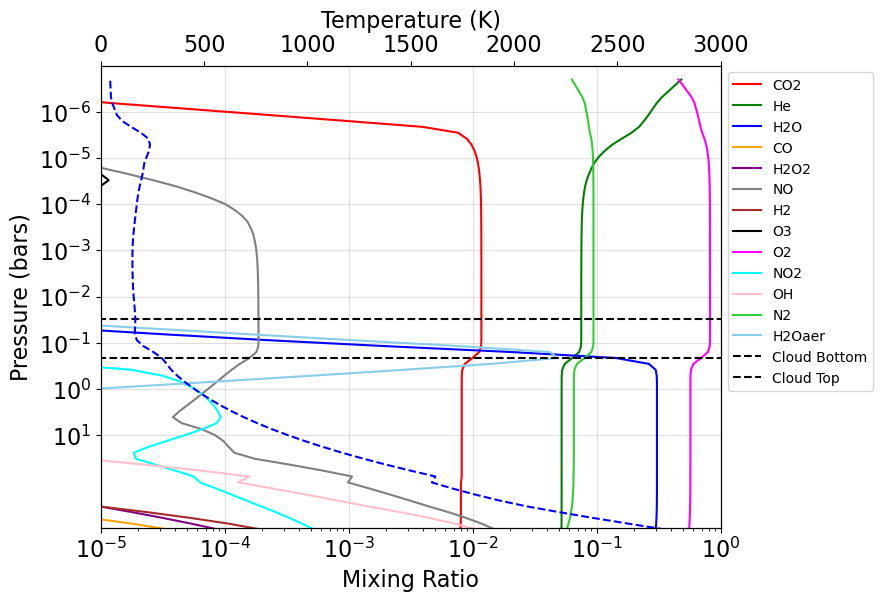

In [26]:
plot_photochem_model_with_cloud(sol=photochem_data_35m_001co_sol, soleq=photochem_data_35m_001co_soleq)

#### Mini Neptune O2 Rich 2x Earth Radii Case:

dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


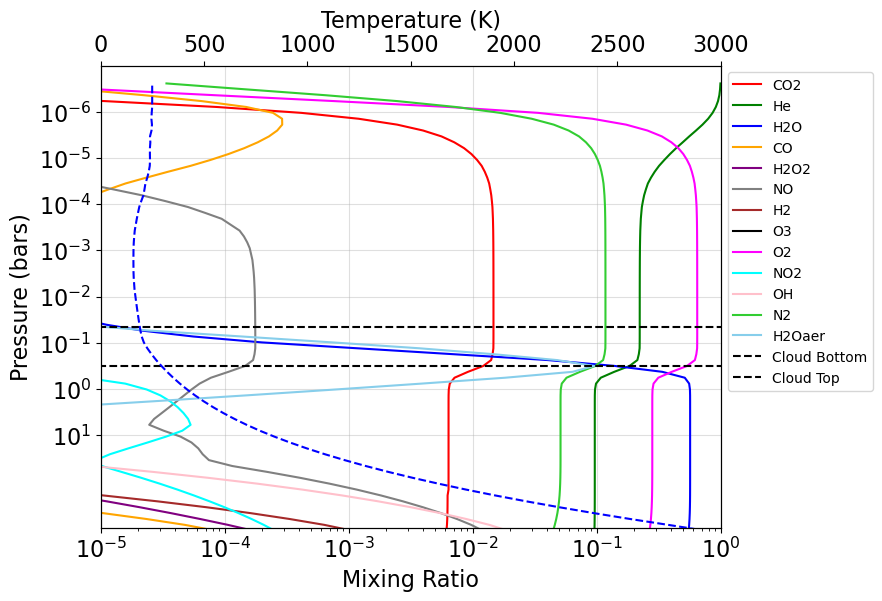

In [27]:
plot_photochem_model_with_cloud(sol=sol_2_3125_200_1_001_5, soleq=soleq_2_3125_200_1_001_5)

#### Mini Neptune H2-CO Rich 2x Earth Radii Case:

dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


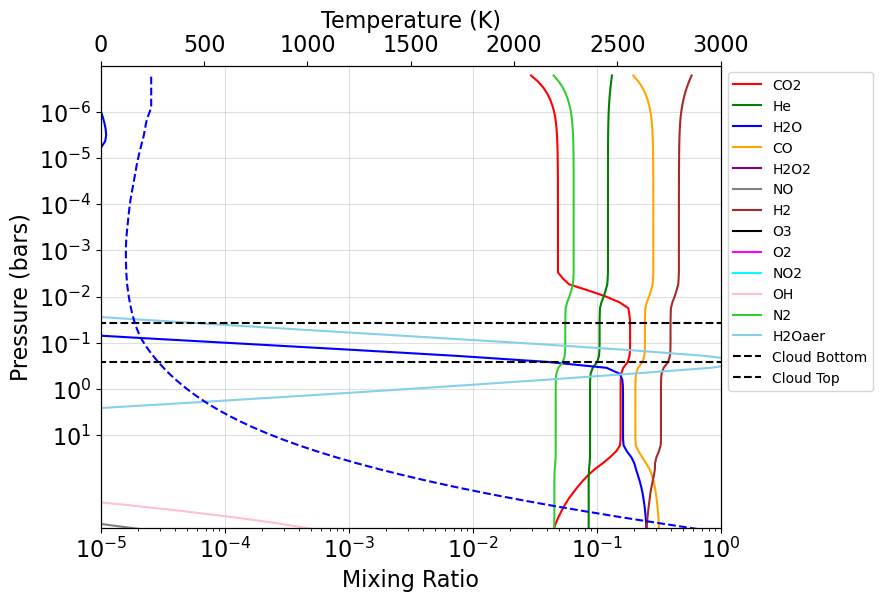

In [28]:
plot_photochem_model_with_cloud(sol=sol_2_3125_200_15_1_7, soleq=soleq_2_3125_200_15_1_7)

First case (a) is the O2-Rich K218b like case, Second Case (b) is the CO-Rich 2x Earth Radius Case
dict_keys(['H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer'])
dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


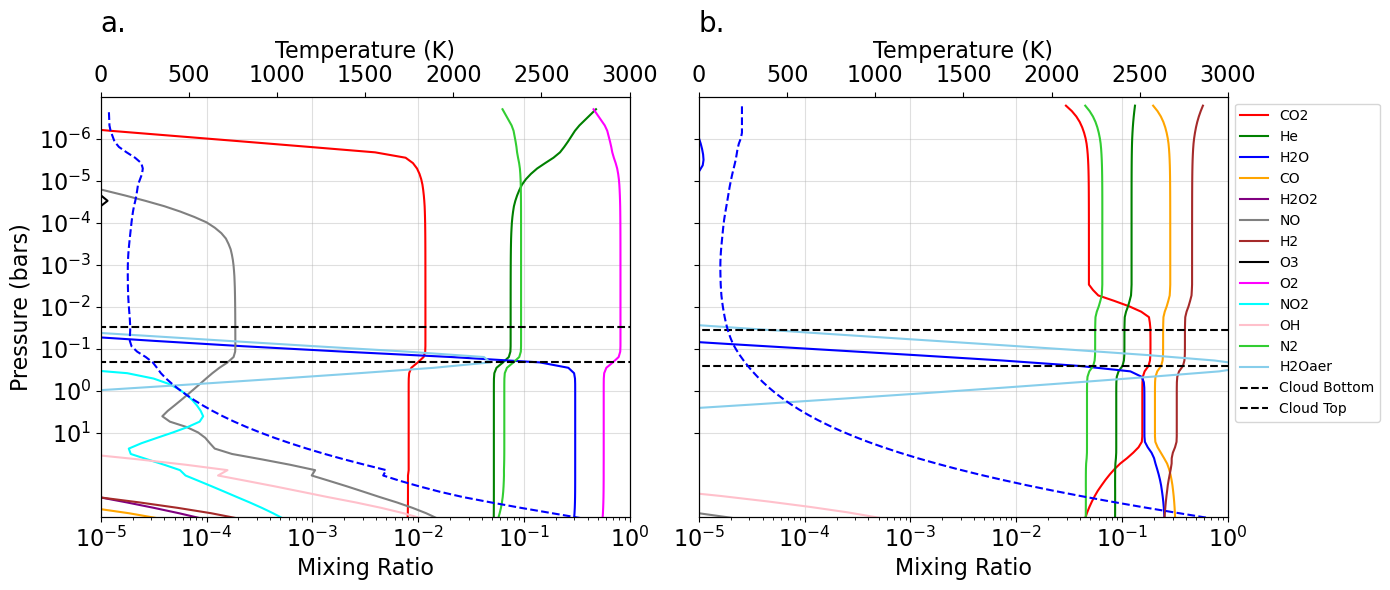

In [29]:
# Create a single panel figure and save for paper

print(f'First case (a) is the O2-Rich K218b like case, Second Case (b) is the CO-Rich 2x Earth Radius Case')
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

plot_photochem_model_with_cloud(sol=photochem_data_35m_001co_sol, soleq=photochem_data_35m_001co_soleq, ax1=axes[0], show_legend=False)
plot_photochem_model_with_cloud(sol=sol_2_3125_200_15_1_7, soleq=soleq_2_3125_200_15_1_7, ax1=axes[1])

axes[1].set_ylabel("")

axes[0].set_title("a.", loc='left', fontsize=20)
axes[1].set_title("b.", loc='left', fontsize=20)

#fig.suptitle("K2-18b Around Sun (G-Star)", fontsize=20)

axes[1].legend(ncol=1, bbox_to_anchor=(1,1.0), loc='upper left')

plt.tight_layout()
plt.show()

### Figure 2 & 3: One panel. Albedo vs. wavelength for Archean Earth and CO-rich sub-Neptune, and for Modern and O2-rich sub-Neptune.

In [11]:
from cycler import cycler

def plot_reflected_spectrum(wno=None, alb=None, inputs=None, legend_label=None, ax1=None, fill_curves=None):
    """
    wno = list of wavenumbers to plot (can be [[],[]]...)
    alb = list of albedos associated with wavenumbers (can be [[],[]...])
    inputs = list of inputs associated with the wavenumbers and albedos (can be [[],[],...]); |
        note inputs should be ordered like radius, metallicity, internal temperature, 
        semi-major axis, c/o ratio, and kzz mixing coefficient.
    legend_label = list of strings describing what dataset you are pulling from
    fill_curves = a float; fills the last fill_curve value of curves
    """
        
    # Define a list of colors or use a color cycle
    colors = ['green', 'red', 'orange']

    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[10,4])

    for index in range(len(wno)):
        if inputs[index] is not None:
            print(f'{inputs[index][0]}_{inputs[index][1]}_{inputs[index][2]}_{inputs[index][3]}_{inputs[index][4]}_{inputs[index][5]}')
        else:
            print(f'Included Earth Plot that does not have inputs.')

        # Fill last two curves
        if fill_curves is not None:
            if index >= len(wno) - fill_curves:
                line, = ax1.plot(1e4/wno[index], alb[index], linestyle='--', lw=0.5, label=legend_label[index])
                ax1.fill_between(1e4/wno[index], alb[index], color=line.get_color(), alpha=0.15)
            else:
                ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label[index])

        else:
            ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label[index])
        
    ax1.set_prop_cycle(cycler(color=['red', 'green', 'blue', 'orange']))

    ax1.set_xlim(0.2, 2)
    #ax1.set_ylim(0, 0.35)
    ax1.set_ylabel('Albedo')
    ax1.set_xlabel('Wavelength (microns)')

    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    if ax1 is None:
        plt.tight_layout()
        
        plt.show()

#### Mini Neptune H2/CO Rich 2x Earth Radii Case:

In [66]:
phase_angle_list = np.linspace(0, np.pi, 19)
phase_earth = phase_angle_list[:-1]
print(phase_earth)

[0.         0.17453293 0.34906585 0.52359878 0.6981317  0.87266463
 1.04719755 1.22173048 1.3962634  1.57079633 1.74532925 1.91986218
 2.0943951  2.26892803 2.44346095 2.61799388 2.7925268  2.96705973]


In [67]:
print((180/np.pi)*phase_earth)

[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170.]


2.0_3.125_200.0_1.5_1.0_7.0
Included Earth Plot that does not have inputs.


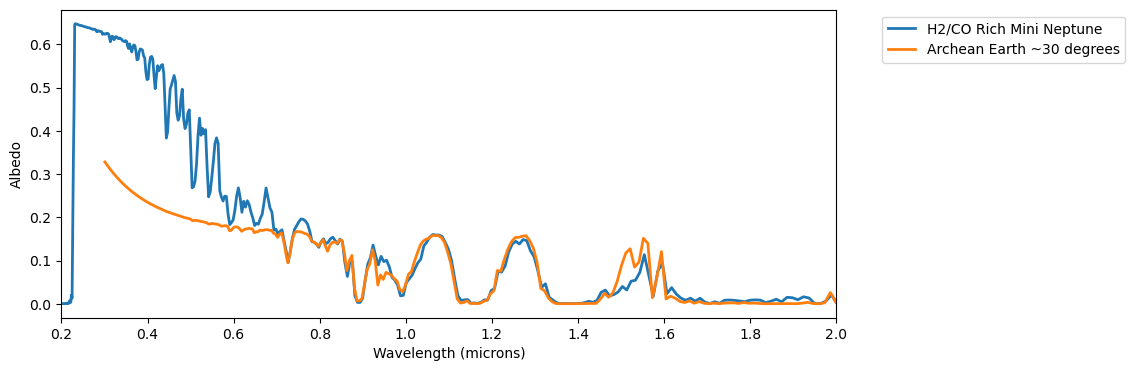

In [68]:
wno_all_CO = [np.array(wno_CORich.copy()), np.array(res_archean_earth_wv_list[3].copy())]
alb_all_CO = [np.array(alb_CORich.copy()), np.array(res_archean_earth_alb_list[3].copy())]
inputs_all_CO = [inputs_list_CORich.copy(), None]
legend_label_all_CO = ['H2/CO Rich Mini Neptune','Archean Earth ~30 degrees']

plot_reflected_spectrum(wno=wno_all_CO, alb=alb_all_CO, inputs=inputs_all_CO, legend_label=legend_label_all_CO)

#### Mini Neptune O2 Rich 2x Earth Radii Case:

2.0_3.125_200.0_1.0_0.01_5.0
Included Earth Plot that does not have inputs.


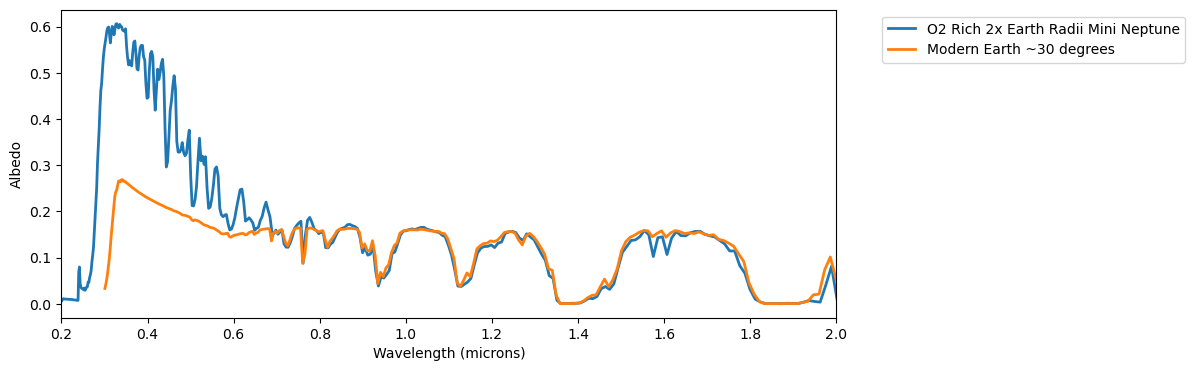

In [69]:
wno_all_O2 = [np.array(wno_O2.copy()), np.array(res_modern_earth_wv_list[3].copy())]
alb_all_O2 = [np.array(alb_O2.copy()), np.array(res_modern_earth_alb_list[3].copy())]
inputs_all_O2 = [inputs_list_O2.copy(), None]
legend_label_all_O2 = ['O2 Rich 2x Earth Radii Mini Neptune','Modern Earth ~30 degrees']

plot_reflected_spectrum(wno=wno_all_O2, alb=alb_all_O2, inputs=inputs_all_O2, legend_label=legend_label_all_O2)

#### Mini Neptune O2 Rich K218-Like Earth Radii Case:

In [70]:
RLS_data_35m_001co.keys()

dict_keys(['wno', 'fpfs', 'alb', 'clouds', 'df_cld', 'df_cldfree'])

2.0_3.125_200.0_1.0_0.01_5.0
Included Earth Plot that does not have inputs.


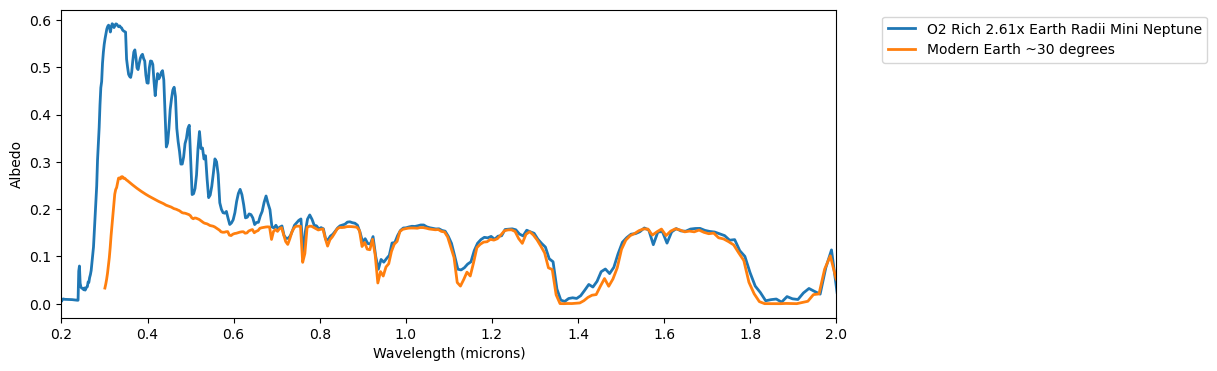

In [71]:
wno_all_O2_K218b = [np.array(RLS_data_35m_001co['wno'].copy()), np.array(res_modern_earth_wv_list[3].copy())]
alb_all_O2_K218b = [np.array(RLS_data_35m_001co['alb'].copy()), np.array(res_modern_earth_alb_list[3].copy())]
inputs_all_O2_K218b = [inputs_list_O2.copy(), None]
legend_label_all_O2_K218b = ['O2 Rich 2.61x Earth Radii Mini Neptune','Modern Earth ~30 degrees']

plot_reflected_spectrum(wno=wno_all_O2_K218b, alb=alb_all_O2_K218b, inputs=inputs_all_O2_K218b, legend_label=legend_label_all_O2_K218b)

#### Combine the plots into a single uploadable figure:

First case (a) is the O2-Rich 2x Earth Radii Case, Second Case (b) is the CO-Rich 2x Earth Radius Case
2.0_3.125_200.0_1.0_0.01_5.0
Included Earth Plot that does not have inputs.
2.0_3.125_200.0_1.5_1.0_7.0
Included Earth Plot that does not have inputs.


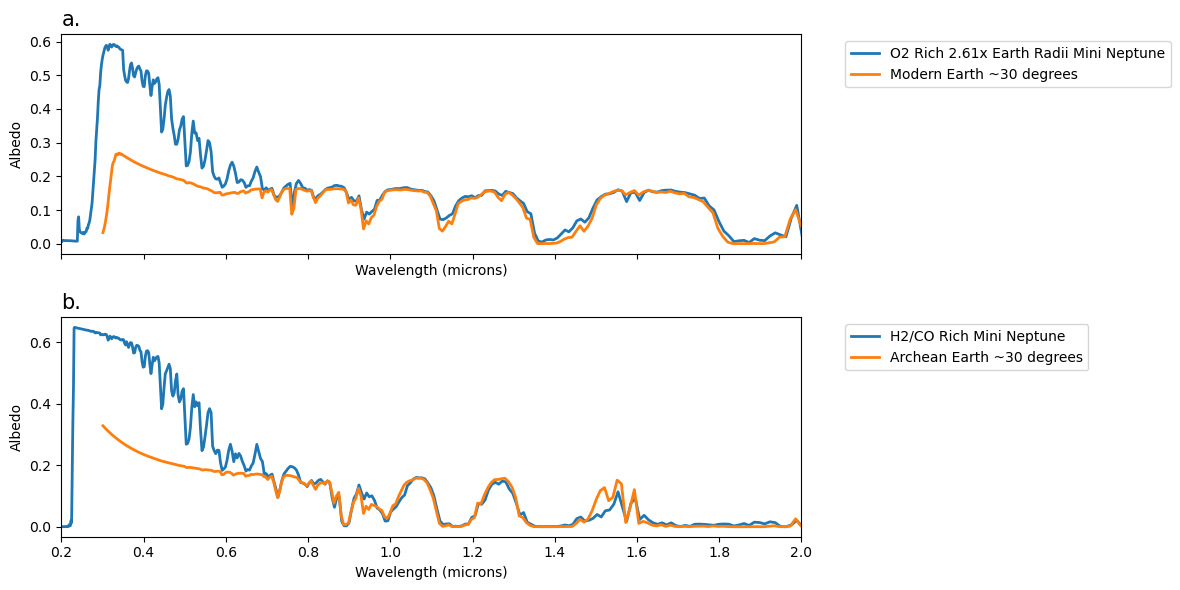

In [72]:
#### Combine the plots into a single uploadable figure:
# Create a single panel figure and save for paper

print(f'First case (a) is the O2-Rich 2x Earth Radii Case, Second Case (b) is the CO-Rich 2x Earth Radius Case')
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex = True)

plot_reflected_spectrum(wno=wno_all_O2_K218b, alb=alb_all_O2_K218b, inputs=inputs_all_O2_K218b, legend_label=legend_label_all_O2_K218b, ax1=axes[0])
plot_reflected_spectrum(wno=wno_all_CO, alb=alb_all_CO, inputs=inputs_all_CO, legend_label=legend_label_all_CO, ax1=axes[1])

#axes[0].set_ylabel("")

axes[0].set_title("a.", loc='left', fontsize=15)
axes[1].set_title("b.", loc='left', fontsize=15)

#fig.suptitle("K2-18b Around Sun (G-Star)", fontsize=20)

axes[1].legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

### Figure 4 & 5: 
- Two panels. One panel is H2-rich. The other is Archean Earth. for both panels show contributions of Molecules, ground, rayleigh scattering, clouds.
- Two panels. One panel is O2-rich. The other is Modern Earth. for both panels show contributions of Molecules, ground, rayleigh scattering, clouds.

To utilize the plot_reflected_spectrum for cases with multiple data points, I need to combine data into wno, alb, inputs, and legend_label lists for these figures!!

#### Figure 4:

##### H2 Rich Contributions (need to add rayleigh scattering)

2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0


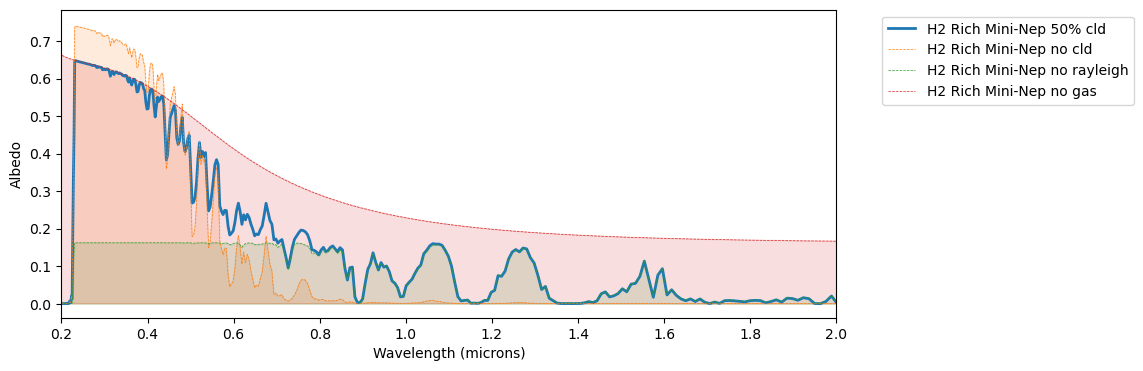

In [93]:
# Compare New with Old
wno_all_H2 = [wno_H2_O2_cld05,  wno_H2_CO_R150_nocld, wno_H2_CO_R150_noray, wno_H2_CO_R150_nogas]
alb_all_H2 = [alb_H2_O2_cld05, alb_H2_CO_R150_nocld, alb_H2_CO_R150_noray, alb_H2_CO_R150_nogas]
inputs_all_H2 = [inputs_list_CORich.copy() , inputs_list_CORich.copy(), inputs_list_CORich.copy(), inputs_list_CORich.copy()]
legend_label_all_H2 = ['H2 Rich Mini-Nep 50% cld','H2 Rich Mini-Nep no cld', 'H2 Rich Mini-Nep no rayleigh', 'H2 Rich Mini-Nep no gas']

plot_reflected_spectrum(wno=wno_all_H2, alb=alb_all_H2, inputs=inputs_all_H2, legend_label=legend_label_all_H2, fill_curves=3)

##### Archean Earth Contributions (need to add rayleigh scatter, ground, clouds, and O3 contributions)

Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


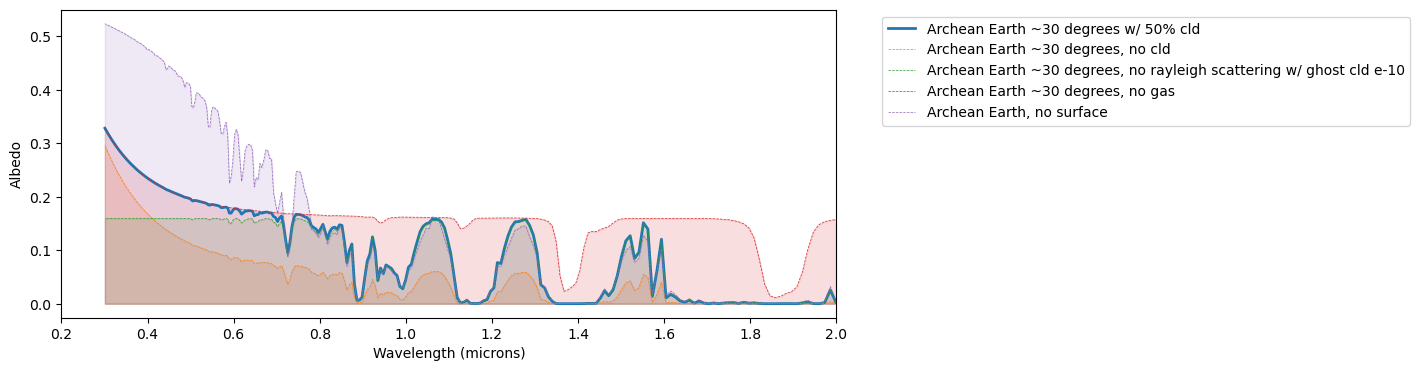

In [74]:
wno_all_archeanearth = [np.array(res_archean_earth_wv_list[3].copy()), earth_results['archean_nocld']['wno'].copy(), wno_ArcheanEarth_noray_30deg, earth_results['archean_nogas']['wno'].copy(), earth_results['archean_deep']['wno'].copy()]
alb_all_archeanearth = [np.array(res_archean_earth_alb_list[3].copy()), earth_results['archean_nocld']['albedo'].copy(), alb_ArcheanEarth_noray_30deg, earth_results['archean_nogas']['albedo'].copy(), earth_results['archean_deep']['albedo'].copy()]
inputs_all_archeanearth = [None, None, None, None, None, None]
legend_label_all_archeanearth = ['Archean Earth ~30 degrees w/ 50% cld', 'Archean Earth ~30 degrees, no cld', 'Archean Earth ~30 degrees, no rayleigh scattering w/ ghost cld e-10', 'Archean Earth ~30 degrees, no gas', 'Archean Earth, no surface']

plot_reflected_spectrum(wno=wno_all_archeanearth, alb=alb_all_archeanearth, inputs=inputs_all_archeanearth, legend_label=legend_label_all_archeanearth, fill_curves=4)

#### Figure 5:

##### O2 Rich Contributions (2x Radius) (need to add rayleigh scatter + ground)

2.0_3.125_200.0_1.0_0.01_5.0
2.0_3.125_200.0_1.0_0.01_5.0
2.0_3.125_200.0_1.0_0.01_5.0
2.0_3.125_200.0_1.0_0.01_5.0


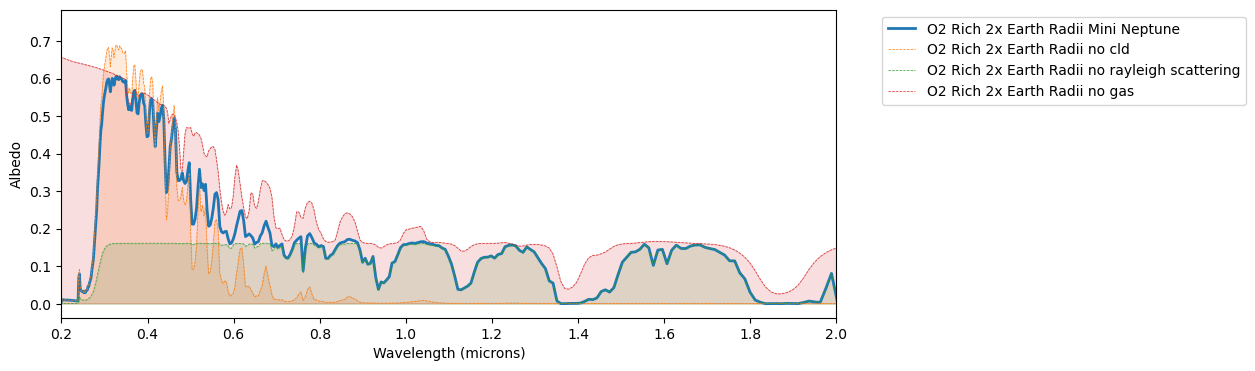

In [12]:
wno_all_O2_r2 = [np.array(wno_O2.copy()), wno_O2Rich_2R_nocld, wno_O2Rich_2R_noray, wno_O2Rich_2R_nogas]
alb_all_O2_r2 = [np.array(alb_O2.copy()), alb_O2Rich_2R_nocld, alb_O2Rich_2R_noray, alb_O2Rich_2R_nogas]
inputs_all_O2_r2 = [inputs_list_O2.copy(), inputs_list_O2.copy(), inputs_list_O2.copy(), inputs_list_O2.copy()]
legend_label_all_O2_r2 = ['O2 Rich 2x Earth Radii Mini Neptune','O2 Rich 2x Earth Radii no cld', 'O2 Rich 2x Earth Radii no rayleigh scattering','O2 Rich 2x Earth Radii no gas']

plot_reflected_spectrum(wno=wno_all_O2_r2, alb=alb_all_O2_r2, inputs=inputs_all_O2_r2, legend_label=legend_label_all_O2_r2, fill_curves=3)

##### O2 Rich Contributions (K218b like) (need to add rayleigh scatter + ground)

In [75]:
gas_results['k218b_noray']['alb']

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5


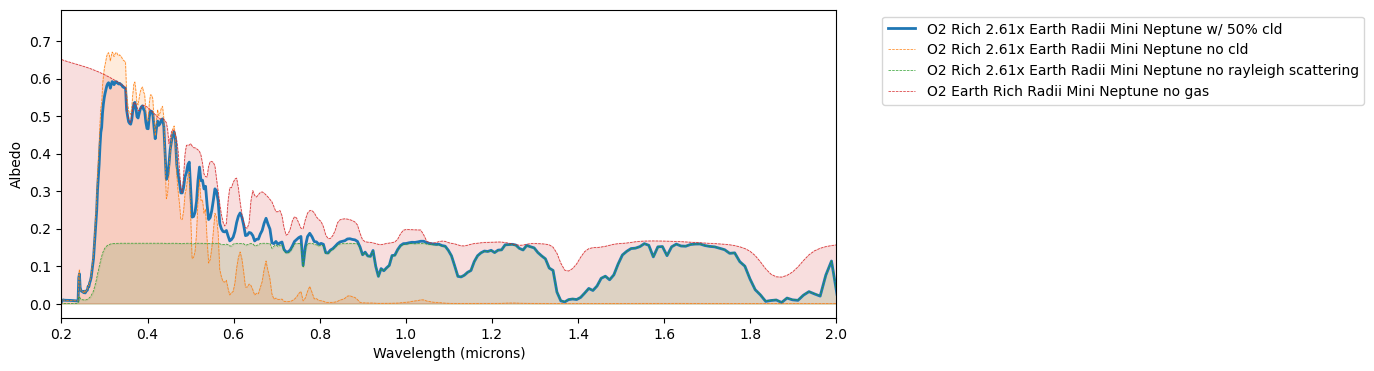

In [76]:
#wno_all_O2_K218b = [gas_results['k218b_nogas']['wno'].copy()]
#alb_all_O2_K218b = [gas_results['k218b_nogas']['alb'].copy()]
#inputs_all_O2_K218b = [[2.61, 3.5, 155, 1, 0.01, 5]]
#legend_label_all_O2_K218b = ['O2 Earth Rich Radii Mini Neptune no gas']


wno_all_O2_K218b = [np.array(RLS_data_35m_001co['wno'].copy()), np.array(RLS_data_35m_001co_nocld['wno'].copy()), wno_O2Rich_K218bRAD2R_noray, gas_results['k218b_nogas']['wno'].copy()]
alb_all_O2_K218b = [np.array(RLS_data_35m_001co['alb'].copy()), np.array(RLS_data_35m_001co_nocld['alb'].copy()), alb_O2Rich_K218bRAD_noray, gas_results['k218b_nogas']['alb'].copy()]
inputs_all_O2_K218b = [[2.61, 3.5, 155, 1, 0.01, 5], [2.61, 3.5, 155, 1, 0.01, 5], [2.61, 3.5, 155, 1, 0.01, 5], [2.61, 3.5, 155, 1, 0.01, 5]]
legend_label_all_O2_K218b = ['O2 Rich 2.61x Earth Radii Mini Neptune w/ 50% cld', 'O2 Rich 2.61x Earth Radii Mini Neptune no cld', 'O2 Rich 2.61x Earth Radii Mini Neptune no rayleigh scattering', 'O2 Earth Rich Radii Mini Neptune no gas']

plot_reflected_spectrum(wno=wno_all_O2_K218b, alb=alb_all_O2_K218b, inputs=inputs_all_O2_K218b, legend_label=legend_label_all_O2_K218b, fill_curves=3)

2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5


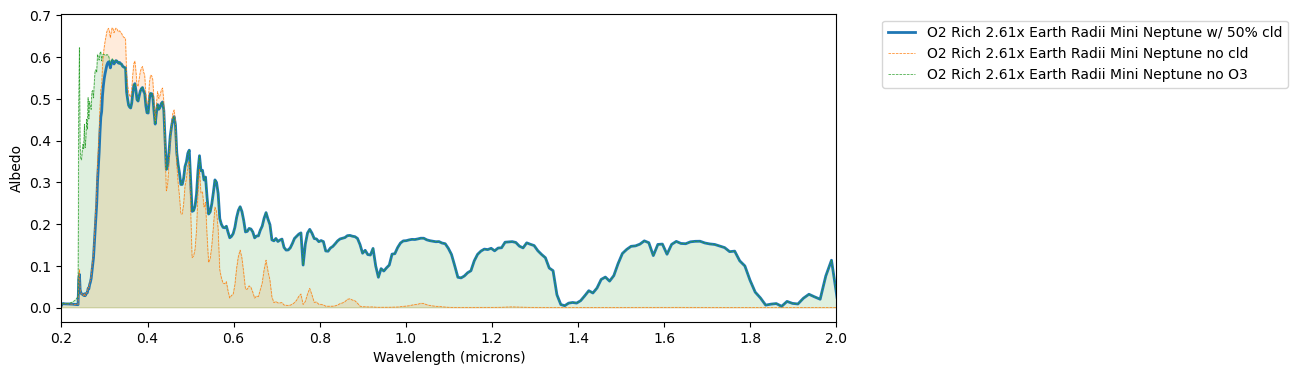

In [77]:
wno_all_O2_K218b = [np.array(RLS_data_35m_001co['wno'].copy()), np.array(RLS_data_35m_001co_nocld['wno'].copy()), np.array(RLS_data_35m_001co_noO3['wno'].copy())]
alb_all_O2_K218b = [np.array(RLS_data_35m_001co['alb'].copy()), np.array(RLS_data_35m_001co_nocld['alb'].copy()), np.array(RLS_data_35m_001co_noO3['alb'].copy())]
inputs_all_O2_K218b = [[2.61, 3.5, 155, 1, 0.01, 5], [2.61, 3.5, 155, 1, 0.01, 5], [2.61, 3.5, 155, 1, 0.01, 5]]
legend_label_all_O2_K218b = ['O2 Rich 2.61x Earth Radii Mini Neptune w/ 50% cld', 'O2 Rich 2.61x Earth Radii Mini Neptune no cld', 'O2 Rich 2.61x Earth Radii Mini Neptune no O3']

plot_reflected_spectrum(wno=wno_all_O2_K218b, alb=alb_all_O2_K218b, inputs=inputs_all_O2_K218b, legend_label=legend_label_all_O2_K218b, fill_curves=2)

##### Modern Earth Contributions (need to add rayleigh scatter, ground, clouds, and O3 contributions)

In [78]:
earth_results['modern_noray']['albedo']

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


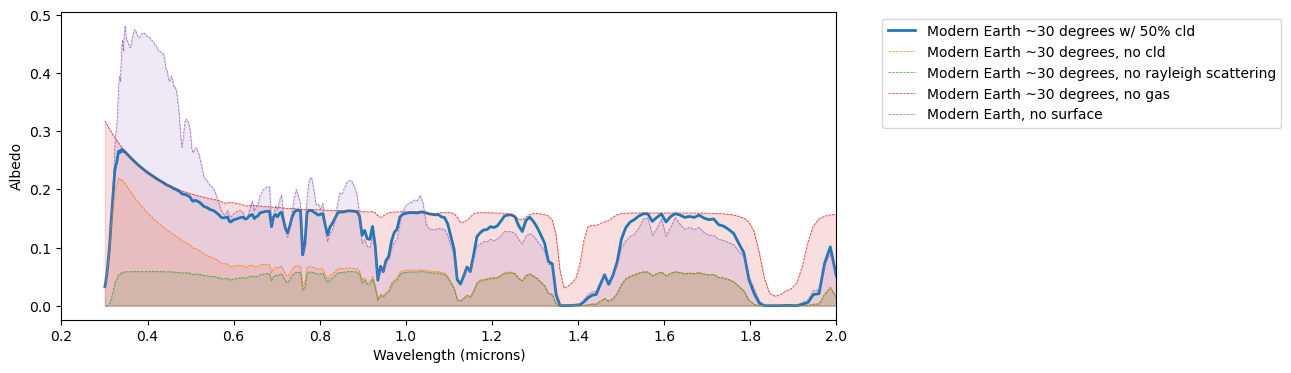

In [79]:
wno_all_modernearth = [np.array(res_modern_earth_wv_list[3].copy()), earth_results['modern_nocld']['wno'].copy(), wno_ModernEarth_noray_30deg, earth_results['modern_nogas']['wno'].copy(), earth_results['modern_deep']['wno'].copy()]
alb_all_modernearth = [np.array(res_modern_earth_alb_list[3].copy()), earth_results['modern_nocld']['albedo'].copy(), alb_ModernEarth_noray_30deg, earth_results['modern_nogas']['albedo'].copy(), earth_results['modern_deep']['albedo'].copy()]
inputs_all_archeanearth = [None, None, None, None, None]
legend_label_all_archeanearth = ['Modern Earth ~30 degrees w/ 50% cld', 'Modern Earth ~30 degrees, no cld', 'Modern Earth ~30 degrees, no rayleigh scattering', 'Modern Earth ~30 degrees, no gas', 'Modern Earth, no surface']

plot_reflected_spectrum(wno=wno_all_modernearth, alb=alb_all_modernearth, inputs=inputs_all_archeanearth, legend_label=legend_label_all_archeanearth, fill_curves=4)

#### Plot Figure 4 & 5 Together and Label

First case (a) is the O2-Rich 2.61x Earth Radii Case, Second Case (b) is Modern Earth at ~30 degrees
2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5
2.61_3.5_155_1_0.01_5
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


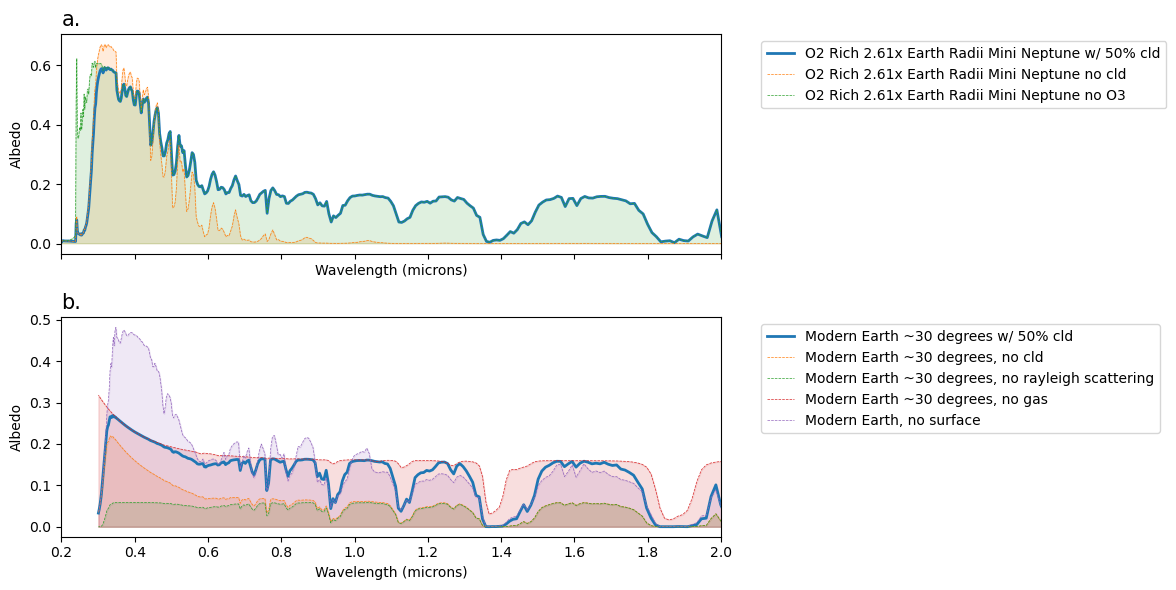

In [80]:
print(f'First case (a) is the O2-Rich 2.61x Earth Radii Case, Second Case (b) is Modern Earth at ~30 degrees')
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex = True)

plot_reflected_spectrum(wno=wno_all_O2_K218b, alb=alb_all_O2_K218b, inputs=inputs_all_O2_K218b, legend_label=legend_label_all_O2_K218b, fill_curves=2, ax1=axes[0])
plot_reflected_spectrum(wno=wno_all_modernearth, alb=alb_all_modernearth, inputs=inputs_all_archeanearth, legend_label=legend_label_all_archeanearth, fill_curves=4, ax1=axes[1])

#axes[0].set_ylabel("")

axes[0].set_title("a.", loc='left', fontsize=15)
axes[1].set_title("b.", loc='left', fontsize=15)

axes[1].legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

First case (a) is the H2-Rich 2x Earth Radii Case, Second Case (b) is Archean Earth at ~30 degrees
2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0
2.0_3.125_200.0_1.5_1.0_7.0
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


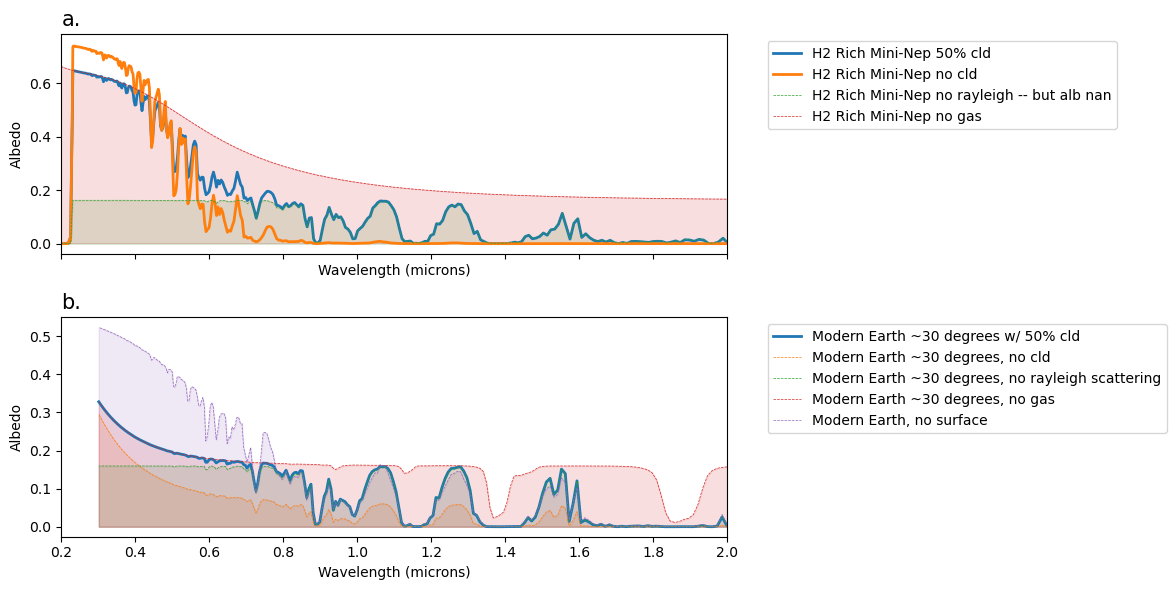

In [81]:
print(f'First case (a) is the H2-Rich 2x Earth Radii Case, Second Case (b) is Archean Earth at ~30 degrees')
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex = True)

plot_reflected_spectrum(wno=wno_all_H2, alb=alb_all_H2, inputs=inputs_all_H2, legend_label=legend_label_all_H2, fill_curves=2, ax1=axes[0])
plot_reflected_spectrum(wno=wno_all_archeanearth, alb=alb_all_archeanearth, inputs=inputs_all_archeanearth, legend_label=legend_label_all_archeanearth, fill_curves=4, ax1=axes[1])

#axes[0].set_ylabel("")

axes[0].set_title("a.", loc='left', fontsize=15)
axes[1].set_title("b.", loc='left', fontsize=15)

axes[1].legend(ncol=1, bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()